# Question 1:  Matplotlib

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data = {
    'Month': ['January', 'February', 'March', 'April', 'May', 'June',
              'July', 'August', 'September', 'October', 'November', 'December'],
    'Attendance (%)': [82, 85, 78, 88, 91, 86, 89, 93, 87, 90, 94, 92]
}

df = pd.DataFrame(data)

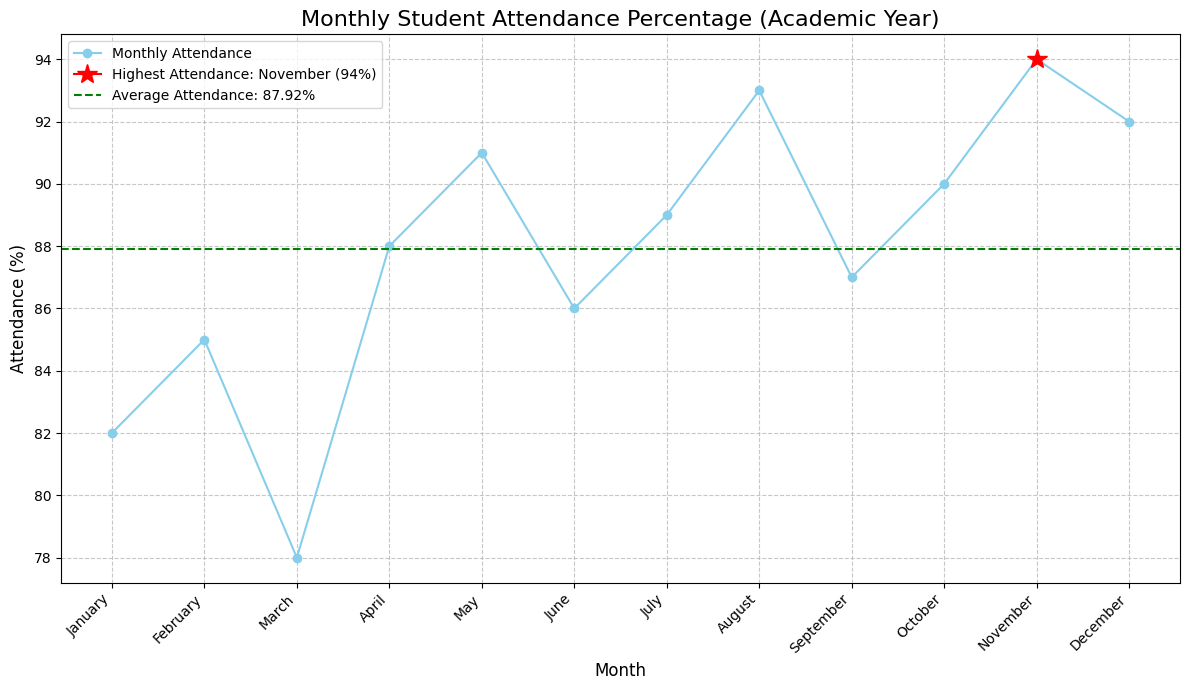

In [ ]:
average_attendance = df['Attendance (%)'].mean()
highest_attendance_month = df.loc[df['Attendance (%)'].idxmax()]

plt.figure(figsize=(12, 7))
plt.plot(df['Month'], df['Attendance (%)'], marker='o', linestyle='-', color='skyblue', label='Monthly Attendance')

plt.title('Monthly Student Attendance Percentage (Academic Year)', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Attendance (%)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

plt.plot(highest_attendance_month['Month'], highest_attendance_month['Attendance (%)'],
         marker='*', markersize=15, color='red', label=f'Highest Attendance: {highest_attendance_month['Month']} ({highest_attendance_month['Attendance (%)']}%)')

plt.axhline(y=average_attendance, color='green', linestyle='--', label=f'Average Attendance: {average_attendance:.2f}%')

plt.xticks(rotation=45, ha='right')

plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"Month with the highest attendance: {highest_attendance_month['Month']} with {highest_attendance_month['Attendance (%)']}% attendance.")
print(f"Average attendance for the year: {average_attendance:.2f}%")

Month with the highest attendance: November with 94% attendance.
Average attendance for the year: 87.92%


# Question 2: Seaborn

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

data = {
    'Experience (Years)': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Salary (₹ Lakhs)': [3.2, 4.1, 5.0, 5.8, 6.5, 7.2, 8.1, 9.0, 9.8, 11.0],
    'Department': ['CSE', 'ECE', 'CSE', 'IT', 'CSE', 'ECE', 'IT', 'CSE', 'ECE', 'IT']
}
df_employees = pd.DataFrame(data)

display(df_employees.head())

,Experience (Years),Salary (₹ Lakhs),Department
0,1,3.2,CSE
1,2,4.1,ECE
2,3,5.0,CSE
3,4,5.8,IT
4,5,6.5,CSE


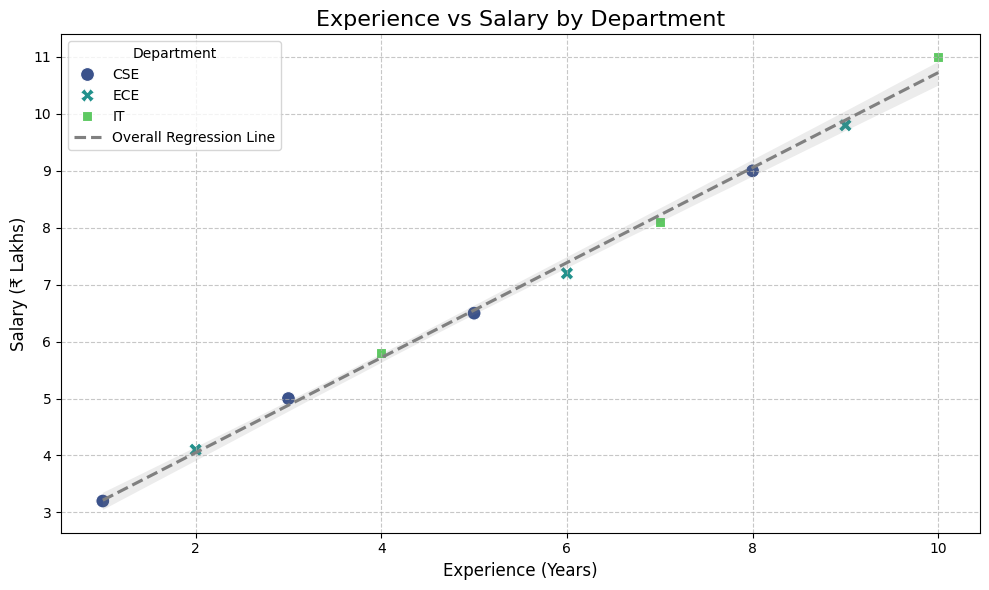

In [ ]:
def plot_experience_salary_scatter(data_frame):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=data_frame, x='Experience (Years)', y='Salary (₹ Lakhs)', hue='Department', style='Department', s=100, palette='viridis')
    sns.regplot(data=data_frame, x='Experience (Years)', y='Salary (₹ Lakhs)', scatter=False, color='gray', line_kws={'linestyle':'--'}, label='Overall Regression Line')

    plt.title('Experience vs Salary by Department', fontsize=16)
    plt.xlabel('Experience (Years)', fontsize=12)
    plt.ylabel('Salary (₹ Lakhs)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title='Department')
    plt.tight_layout()
    plt.show()

plot_experience_salary_scatter(df_employees)

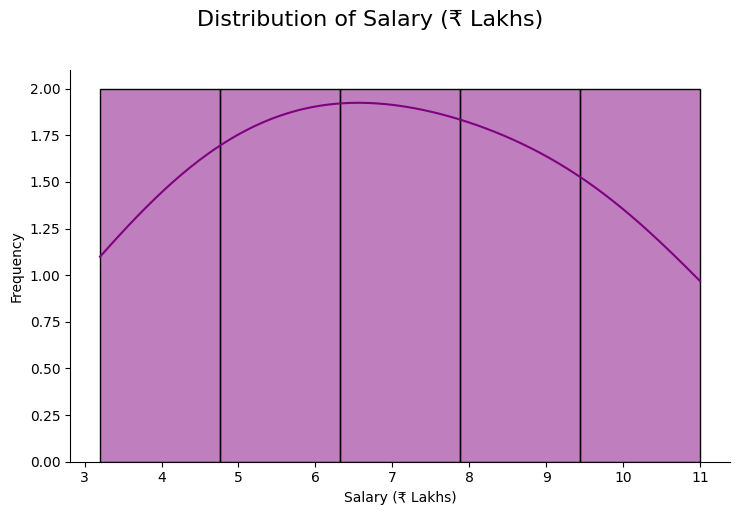

In [ ]:
def plot_salary_distribution(data_frame):
    g = sns.displot(data=data_frame, x='Salary (₹ Lakhs)', kde=True, bins=5, color='purple', height=5, aspect=1.5)
    g.set_axis_labels('Salary (₹ Lakhs)', 'Frequency')
    g.fig.suptitle('Distribution of Salary (₹ Lakhs)', y=1.02, fontsize=16)
    g.tight_layout()
    plt.show()

plot_salary_distribution(df_employees)

/tmp/ipykernel_373/851196797.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(data=data_frame, x='Department', y='Salary (₹ Lakhs)', kind='box', palette='plasma', height=6, aspect=1.5)


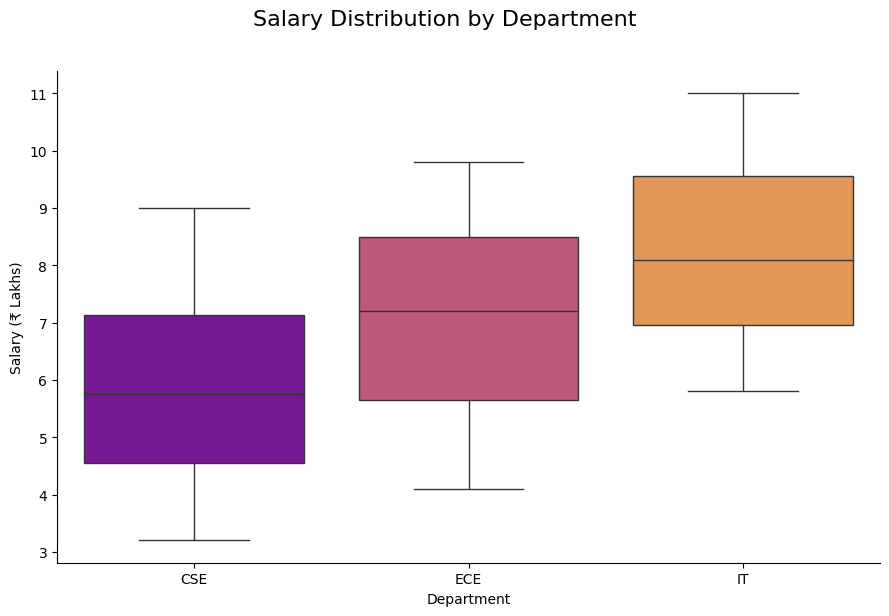

In [ ]:
def plot_departmental_salary_boxplot(data_frame):
    g = sns.catplot(data=data_frame, x='Department', y='Salary (₹ Lakhs)', kind='box', palette='plasma', height=6, aspect=1.5)
    g.set_axis_labels('Department', 'Salary (₹ Lakhs)')
    g.fig.suptitle('Salary Distribution by Department', y=1.02, fontsize=16)
    g.tight_layout()
    plt.show()

plot_departmental_salary_boxplot(df_employees)

# Question 3: Simple Linear Regression for House Price Prediction

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Provided data
data = {
    'Area (sq.ft.)': [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000],
    'Price (₹ Lakhs)': [32, 40, 48, 55, 63, 70, 78, 85, 94, 102, 110, 118]
}
df_house = pd.DataFrame(data)

display(df_house.head())

,Area (sq.ft.),Price (₹ Lakhs)
0,800,32
1,1000,40
2,1200,48
3,1400,55
4,1600,63


### 2. Basic Data Analysis and Missing Values Check

In [ ]:
print(df_house.info())
print('\nMissing values:\n', df_house.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Area (sq.ft.)    12 non-null     int64
 1   Price (₹ Lakhs)  12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes
None

Missing values:
 Area (sq.ft.)      0
Price (₹ Lakhs)    0
dtype: int64


### 3. Split the dataset into training and testing sets

In [ ]:
X = df_house[['Area (sq.ft.)']]
y = df_house['Price (₹ Lakhs)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 9 samples
Testing set size: 3 samples


### 4. Train a Linear Regression model

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### 5. Display the coefficient (slope) and intercept of the model

In [ ]:
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficient (Slope): 0.0387
Intercept: 0.8869


### 6. Predict house prices for the test data

In [ ]:
y_pred = model.predict(X_test)
predictions_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
display(predictions_df)

,Actual Price,Predicted Price
10,110,109.347765
9,102,101.600559
0,32,31.875698


### 7. Calculate and display evaluation metrics

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.39
Mean Squared Error (MSE): 0.20
Root Mean Squared Error (RMSE): 0.45
R² Score: 0.9998


### 8. Plot the actual prices vs predicted prices

/tmp/ipykernel_373/3784116127.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')


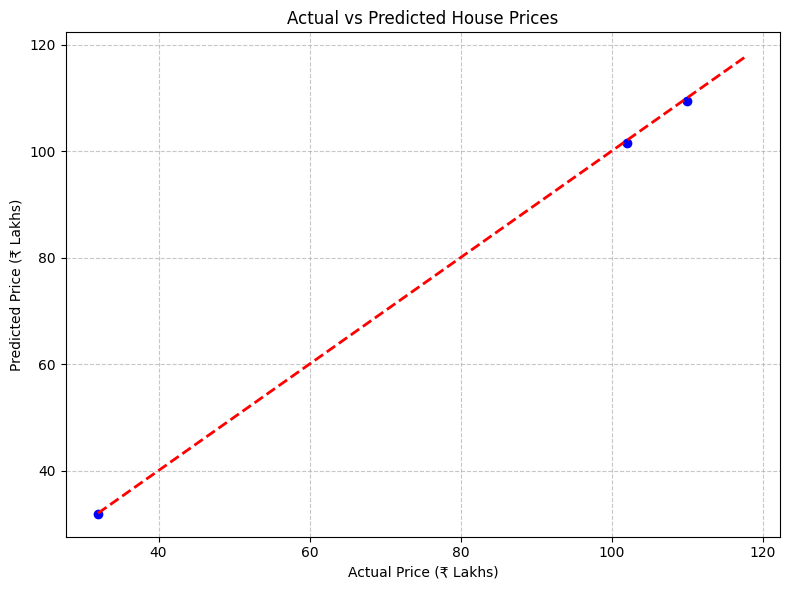

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')
plt.xlabel('Actual Price (₹ Lakhs)')
plt.ylabel('Predicted Price (₹ Lakhs)')
plt.title('Actual vs Predicted House Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 9. Plot the regression line along with the original data points

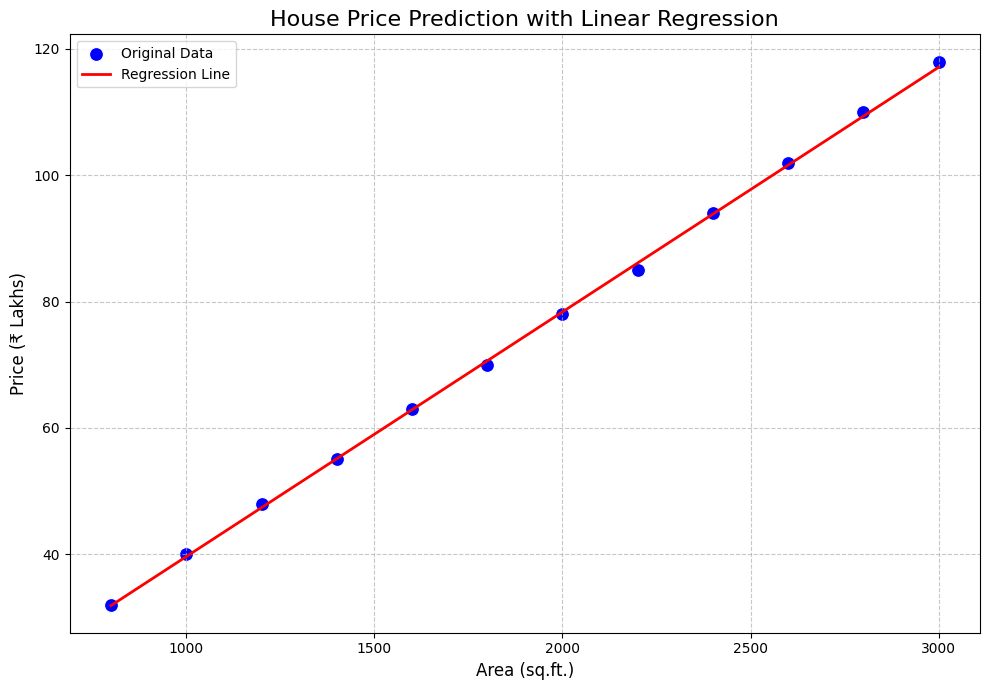

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_house, x='Area (sq.ft.)', y='Price (₹ Lakhs)', s=100, color='blue', label='Original Data')
plt.plot(X, model.predict(X), color='red', linestyle='-', linewidth=2, label='Regression Line')

plt.title('House Price Prediction with Linear Regression', fontsize=16)
plt.xlabel('Area (sq.ft.)', fontsize=12)
plt.ylabel('Price (₹ Lakhs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

### 10. Predict the price of a house having an area of 2500 sq.ft.

In [ ]:
area_to_predict = np.array([[2500]])
predicted_price = model.predict(area_to_predict)
print(f"Predicted price for a house with an area of 2500 sq.ft.: ₹ {predicted_price[0]:.2f} Lakhs")

Predicted price for a house with an area of 2500 sq.ft.: ₹ 97.73 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Area (sq.ft.)': [800, 1000, 1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000],
    'Price (₹ Lakhs)': [32, 40, 48, 55, 63, 70, 78, 85, 94, 102, 110, 118]
}
df_house = pd.DataFrame(data)

display(df_house.head())

,Area (sq.ft.),Price (₹ Lakhs)
0,800,32
1,1000,40
2,1200,48
3,1400,55
4,1600,63


In [ ]:
print(df_house.info())
print('\nMissing values:\n', df_house.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Area (sq.ft.)    12 non-null     int64
 1   Price (₹ Lakhs)  12 non-null     int64
dtypes: int64(2)
memory usage: 324.0 bytes
None

Missing values:
 Area (sq.ft.)      0
Price (₹ Lakhs)    0
dtype: int64


In [ ]:
X = df_house[['Area (sq.ft.)']]
y = df_house['Price (₹ Lakhs)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 9 samples
Testing set size: 3 samples


In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(f"Coefficient (Slope): {model.coef_[0]:.4f}")
print(f"Intercept: {model.intercept_:.4f}")

Coefficient (Slope): 0.0387
Intercept: 0.8869


In [ ]:
y_pred = model.predict(X_test)
predictions_df = pd.DataFrame({'Actual Price': y_test, 'Predicted Price': y_pred})
display(predictions_df)

,Actual Price,Predicted Price
10,110,109.347765
9,102,101.600559
0,32,31.875698


In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.39
Mean Squared Error (MSE): 0.20
Root Mean Squared Error (RMSE): 0.45
R² Score: 0.9998


/tmp/ipykernel_373/3784116127.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k--" (-> color='k'). The keyword argument will take precedence.
  plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')


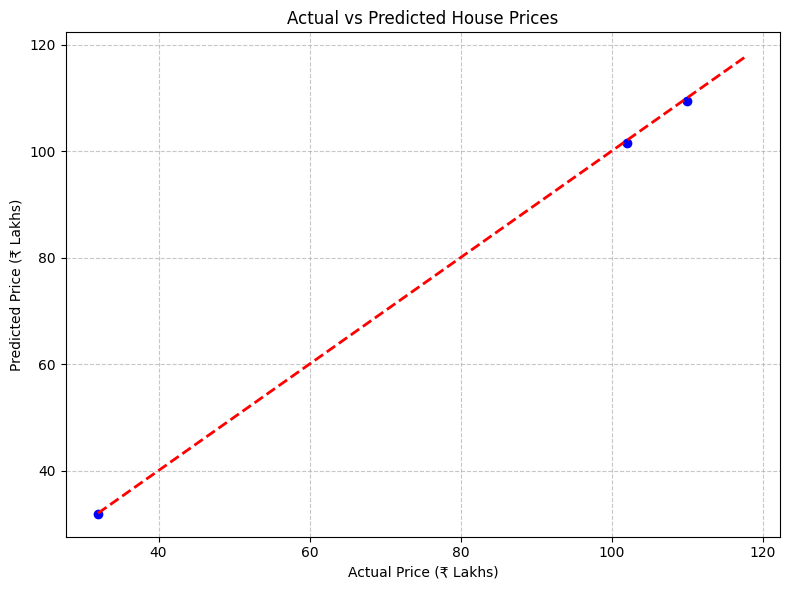

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2, color='red')
plt.xlabel('Actual Price (₹ Lakhs)')
plt.ylabel('Predicted Price (₹ Lakhs)')
plt.title('Actual vs Predicted House Prices')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

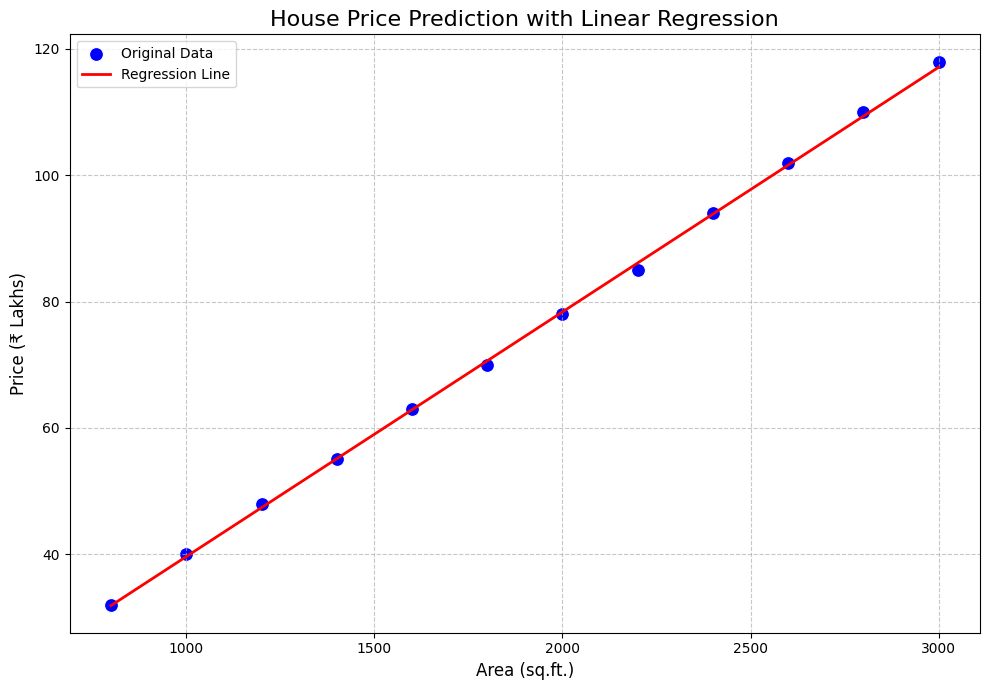

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_house, x='Area (sq.ft.)', y='Price (₹ Lakhs)', s=100, color='blue', label='Original Data')
plt.plot(X, model.predict(X), color='red', linestyle='-', linewidth=2, label='Regression Line')

plt.title('House Price Prediction with Linear Regression', fontsize=16)
plt.xlabel('Area (sq.ft.)', fontsize=12)
plt.ylabel('Price (₹ Lakhs)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
area_to_predict = np.array([[2500]])
predicted_price = model.predict(area_to_predict)
print(f"Predicted price for a house with an area of 2500 sq.ft.: ₹ {predicted_price[0]:.2f} Lakhs")

Predicted price for a house with an area of 2500 sq.ft.: ₹ 97.73 Lakhs


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
